Selected timestep with reef: 2017-08-26T02:30:00.000000000
Selected timestep without reef: 2017-08-26T02:30:00.000000000


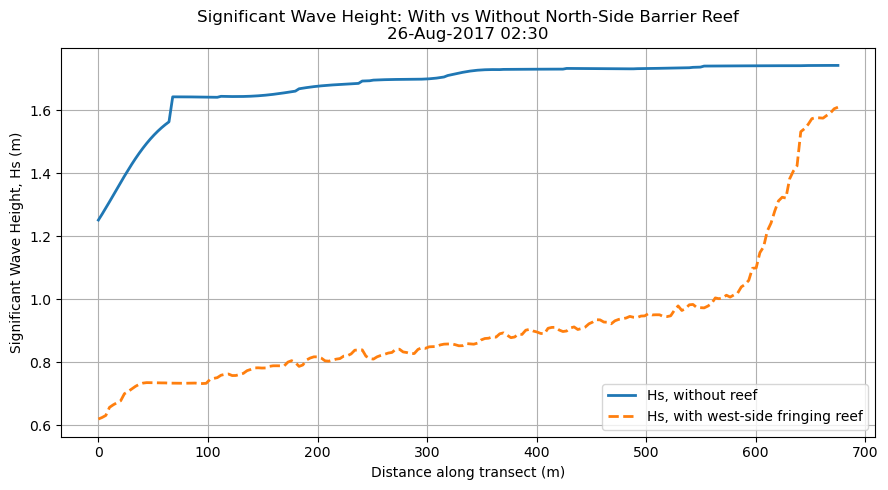

In [3]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# DFSU files
dfsu_with_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_fringing_reef.sw - Result Files\west_side_fringing_reef.dfsu"

dfsu_without_reef = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey.sw - Result Files\small_scale_wave_result.dfsu"

# Transect endpoints
x1, y1 = 729827, 3174795
x2, y2 = 730232, 3175335

n_points = 200

x_line = np.linspace(x1, x2, n_points)
y_line = np.linspace(y1, y2, n_points)
coords = np.column_stack([x_line, y_line])

# Target time
target_time = np.datetime64("2017-08-26T02:30:00")

# Distance along transect
distance = np.sqrt(
    (x_line - x_line[0])**2 +
    (y_line - y_line[0])**2
)

def extract_profile(dfsu_file, item_name):
    dfs = mikeio.open(dfsu_file)
    ds = dfs.read(items=[item_name])

    time_index = np.argmin(np.abs(ds.time.values - target_time))
    selected_time = ds.time.values[time_index]

    da = ds[item_name].isel(time=time_index)

    elem_ids, weights = da.geometry.get_2d_interpolant(
        coords,
        n_nearest=3,
        extrapolate=False
    )

    profile = da.geometry.interp2d(
        da,
        elem_ids,
        weights
    ).flatten()

    return profile, selected_time

# Extract Hs profiles
hs_with_reef, time_with_reef = extract_profile(
    dfsu_with_reef,
    "Sign. Wave Height"
)

hs_without_reef, time_without_reef = extract_profile(
    dfsu_without_reef,
    "Sign. Wave Height"
)

print("Selected timestep with reef:", time_with_reef)
print("Selected timestep without reef:", time_without_reef)

# Plot Hs only
plt.figure(figsize=(9, 5))

plt.plot(
    distance,
    hs_without_reef,
    linewidth=2,
    label="Hs, without reef"
)

plt.plot(
    distance,
    hs_with_reef,
    linewidth=2,
    linestyle="--",
    label="Hs, with west-side fringing reef"
)

plt.xlabel("Distance along transect (m)")
plt.ylabel("Significant Wave Height, Hs (m)")
plt.title("Significant Wave Height: With vs Without North-Side Barrier Reef\n26-Aug-2017 02:30")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()